In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Assessment-III.csv')

In [3]:
df.head()

,customer_id,age,annual_income_usd,spending_score,website_visits_per_month,avg_purchase_value_usd,days_since_last_purchase
0,C001,26.0,30530.0,38,25.0,NaN,44.0
1,C002,23.0,NaN,51,29.0,56.92,65.0
2,C003,NaN,27749.0,16,28.0,NaN,53.0
3,C004,30.0,NaN,37,26.0,22.72,35.0
4,C005,23.0,15000.0,38,20.0,83.39,38.0


In [4]:
df.isnull().sum()

customer_id                  0
age                         16
annual_income_usd           18
spending_score               0
website_visits_per_month    14
avg_purchase_value_usd      20
days_since_last_purchase    12
dtype: int64

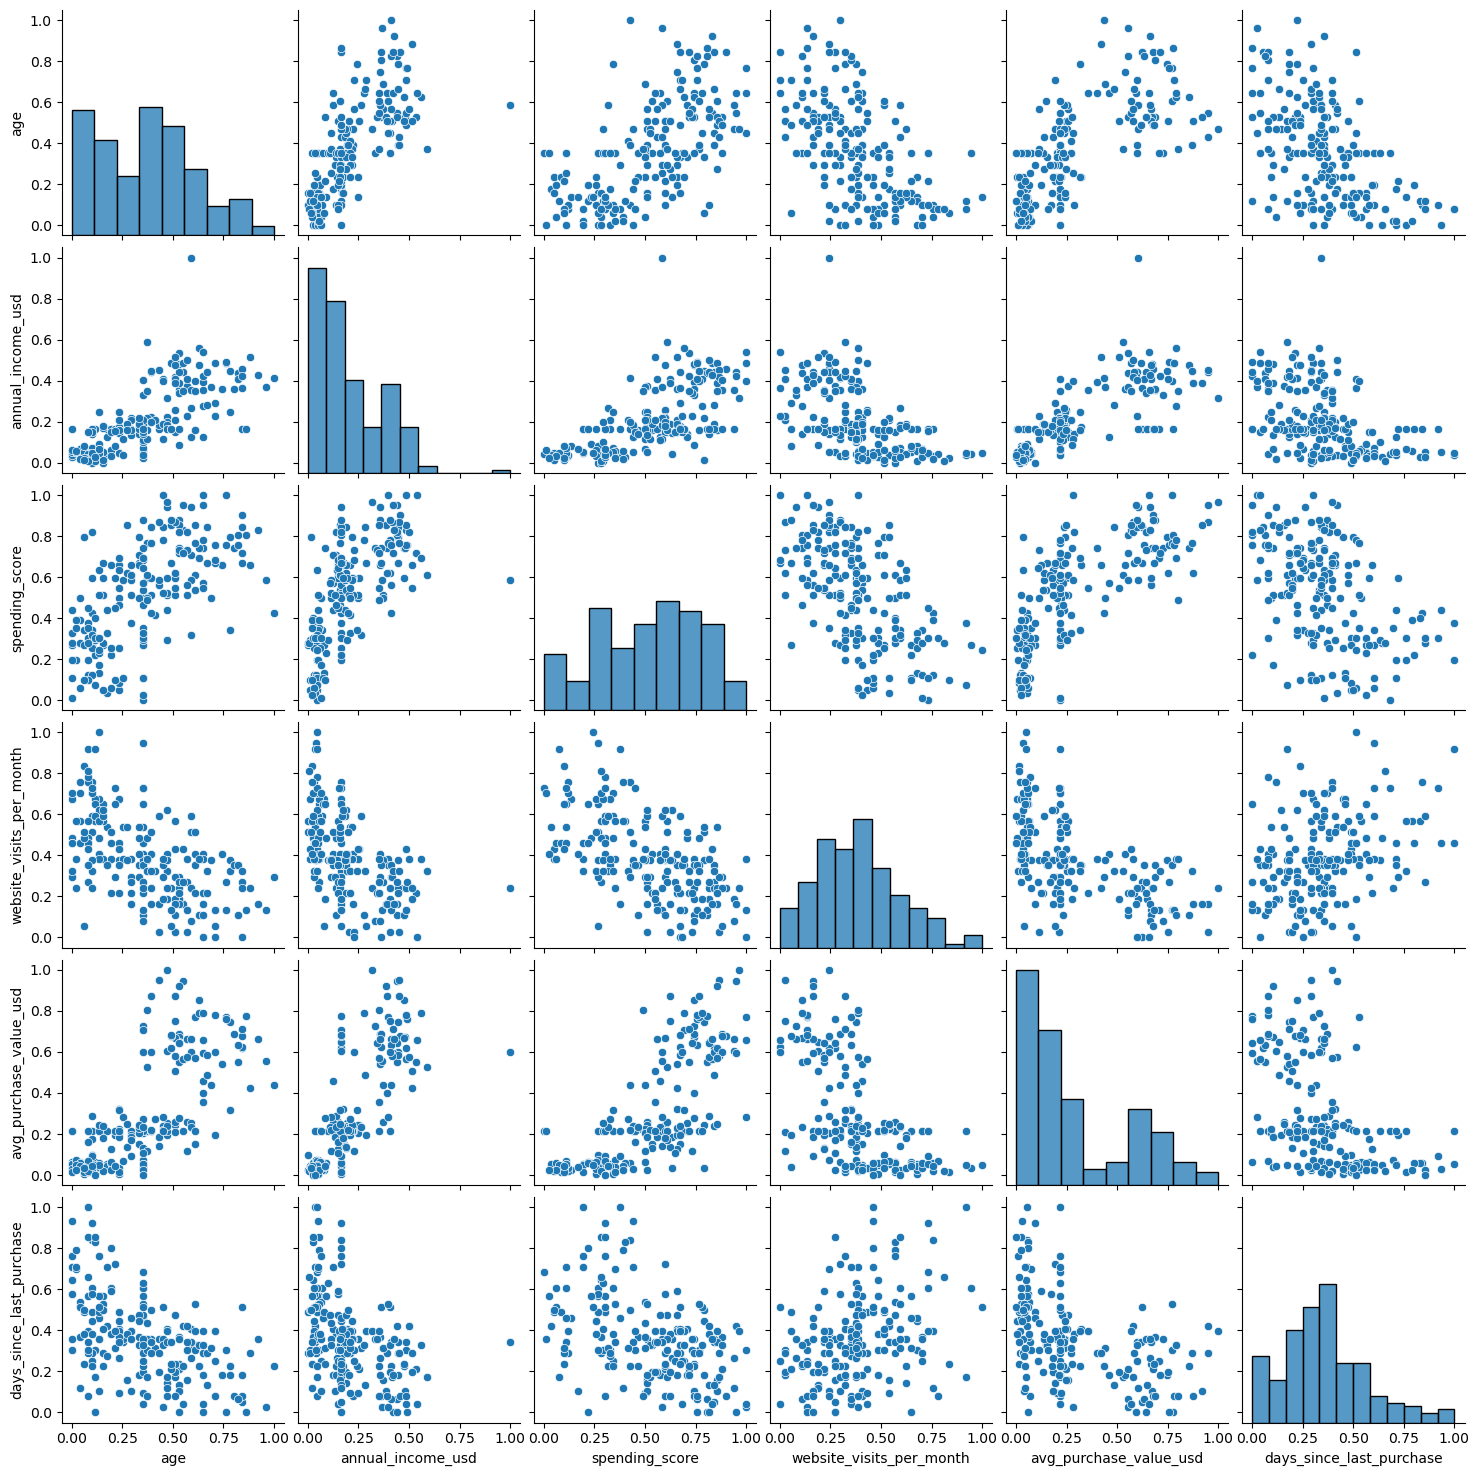

In [64]:
sns.pairplot(data = df)

<Axes: xlabel='annual_income_usd', ylabel='Density'>

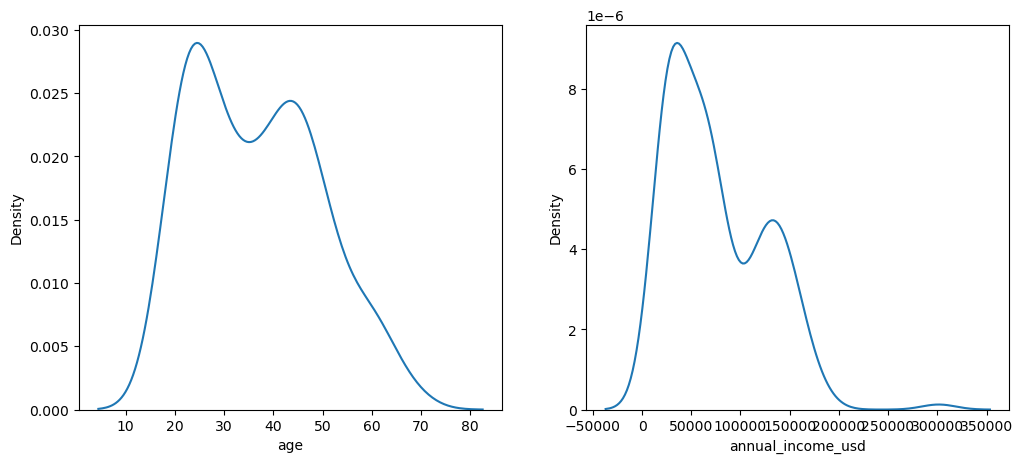

In [32]:
ig, (ax1,ax2)=plt.subplots(ncols = 2, figsize = (12,5))

sns.kdeplot(df['age'] , ax = ax1)
sns.kdeplot(df['annual_income_usd'],ax = ax2)

(array([38., 26., 21., 19., 18., 27., 15.,  8.,  9.,  3.]),
 array([18. , 23.1, 28.2, 33.3, 38.4, 43.5, 48.6, 53.7, 58.8, 63.9, 69. ]),
 <BarContainer object of 10 artists>)

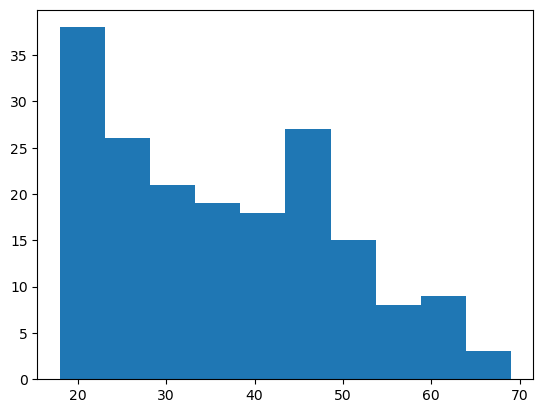

In [34]:
plt.hist(df['age'])

<Axes: xlabel='avg_purchase_value_usd', ylabel='Density'>

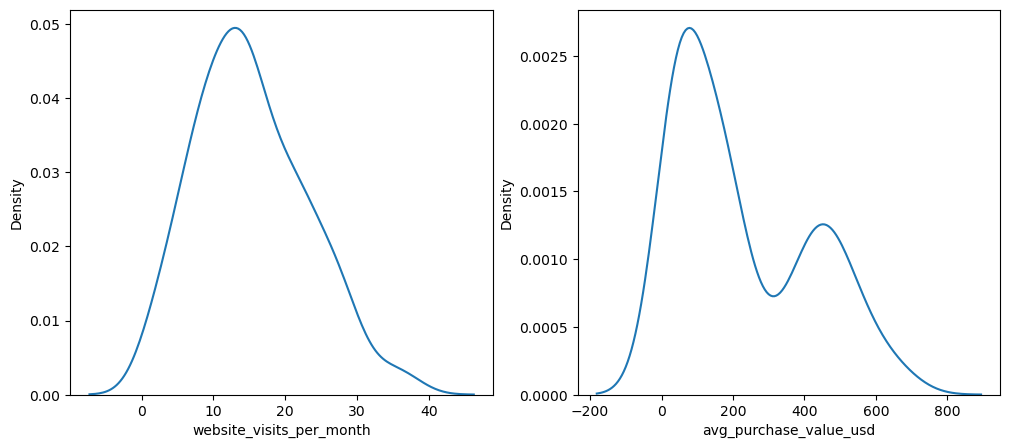

In [35]:
ig, (ax1,ax2)=plt.subplots(ncols = 2, figsize = (12,5))

sns.kdeplot(df['website_visits_per_month'] , ax = ax1)
sns.kdeplot(df['avg_purchase_value_usd'],ax = ax2)

<Axes: xlabel='days_since_last_purchase', ylabel='Density'>

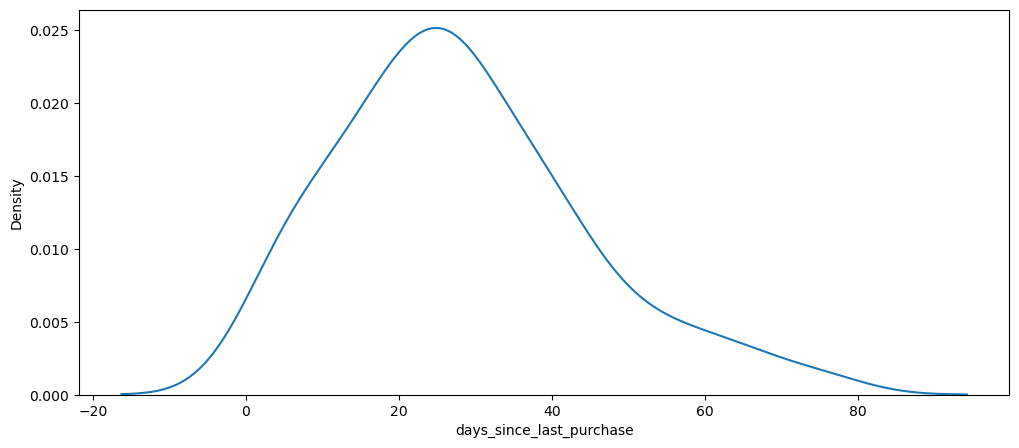

In [36]:
ig, (ax1)=plt.subplots(ncols = 1, figsize = (12,5))

sns.kdeplot(df['days_since_last_purchase'] , ax = ax1)

In [52]:
df['age']=df['age'].fillna(df['age'].median())#skewed

In [51]:
df['annual_income_usd']=df['annual_income_usd'].fillna(df['annual_income_usd'].median())#skewed

In [50]:
df['website_visits_per_month']=df['website_visits_per_month'].fillna(df['website_visits_per_month'].mean())#normal

In [49]:
df['days_since_last_purchase'] = df['days_since_last_purchase'].fillna(df['days_since_last_purchase'].mean())#normal

In [46]:
df['avg_purchase_value_usd']=df['avg_purchase_value_usd'].fillna(df['avg_purchase_value_usd'].median())#skewed


In [54]:
df.isnull().sum()

customer_id                 0
age                         0
annual_income_usd           0
spending_score              0
website_visits_per_month    0
avg_purchase_value_usd      0
days_since_last_purchase    0
dtype: int64

In [53]:
df.head(50)

,customer_id,age,annual_income_usd,spending_score,website_visits_per_month,avg_purchase_value_usd,days_since_last_purchase
0,C001,26.0,30530.0,38,25.000000,164.615,44.00000
1,C002,23.0,61616.5,51,29.000000,56.920,65.00000
2,C003,36.0,27749.0,16,28.000000,164.615,53.00000
3,C004,30.0,61616.5,37,26.000000,22.720,35.00000
4,C005,23.0,15000.0,38,20.000000,83.390,38.00000
5,C006,23.0,33753.0,44,27.000000,164.615,20.00000
6,C007,30.0,28609.0,20,17.000000,42.270,38.00000
7,C008,27.0,25907.0,19,21.000000,55.590,33.00000
8,C009,22.0,28642.0,41,19.000000,50.060,44.00000
9,C010,26.0,15000.0,39,22.000000,33.790,23.00000


In [57]:
def min_max(X):
    return (X-np.min(X,axis=0))/ (np.max(X,axis = 0)-np.min(X,axis=0))
    


In [62]:
df['age']=min_max(df['age'])
df['annual_income_usd']=min_max(df['annual_income_usd'])
df['spending_score']=min_max(df['spending_score'])
df['website_visits_per_month']=min_max(df['website_visits_per_month'])
df['avg_purchase_value_usd']=min_max(df['avg_purchase_value_usd'])
df['days_since_last_purchase']=min_max(df['days_since_last_purchase'])

In [63]:
df.head(10)

,customer_id,age,annual_income_usd,spending_score,website_visits_per_month,avg_purchase_value_usd,days_since_last_purchase
0,C001,0.156863,0.054213,0.268293,0.648649,0.215686,0.565789
1,C002,0.098039,0.162731,0.426829,0.756757,0.056244,0.842105
2,C003,0.352941,0.044505,0.000000,0.729730,0.215686,0.684211
3,C004,0.235294,0.162731,0.256098,0.675676,0.005611,0.447368
4,C005,0.098039,0.000000,0.268293,0.513514,0.095433,0.486842
5,C006,0.098039,0.065464,0.341463,0.702703,0.215686,0.250000
6,C007,0.235294,0.047507,0.048780,0.432432,0.034555,0.486842
7,C008,0.176471,0.038075,0.036585,0.540541,0.054275,0.421053
8,C009,0.078431,0.047622,0.304878,0.486486,0.046088,0.565789
9,C010,0.156863,0.000000,0.280488,0.567568,0.022000,0.289474


In [ ]:
def k_mean():
    